In [3]:
# ================================
# LEUKEMIA MODEL DEVELOPMENT
# YOLO11 – BINARY CLASSIFICATION
# ALLNeg vs ALLPos
# ================================

# -------- 1. INSTALL DEPENDENCIES --------
!pip install -q ultralytics scikit-learn

# -------- 2. IMPORTS --------
import os
import sys
import csv
import random
import numpy as np
from datetime import datetime
from google.colab import drive
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from PIL import Image

# -------- 3. MOUNT GOOGLE DRIVE --------
drive.mount("/content/drive")

# -------- 4. PREPROCESSING FILE --------
# Ensure your preprocessing script is available in the specified path
PREPROCESSING_PATH = "/content/preprocessing_leukemia_yolo.py"
sys.path.append(os.path.dirname(PREPROCESSING_PATH))

import preprocessing_leukemia_yolo
from preprocessing_leukemia_yolo import preprocess_leukemia_yolo

# -------- 5. PATH CONFIGURATION --------
RAW_DATA_DIR = "/content/drive/MyDrive/Research/DataFolder"
DATASET_DIR = "/content/drive/MyDrive/Research/leukemia_cleaned_yolo_11"
RESULTS_DIR = "/content/drive/MyDrive/Research/Results_YOLO11"
LOG_FILE = os.path.join(RESULTS_DIR, "yolo11_training_logs.csv")

os.makedirs(RESULTS_DIR, exist_ok=True)

# -------- 6. RUN PREPROCESSING --------
preprocess_leukemia_yolo(
    input_path=RAW_DATA_DIR,
    output_path=DATASET_DIR
)

# -------- 7. LOAD YOLO11 CLASSIFICATION MODEL --------
# Use "yolo11n-cls.pt" for the new YOLO11 architecture
model = YOLO("yolo11n-cls.pt")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset reorganized
✅ Train / Val / Test split completed


In [4]:
# -------- 8. TRAIN MODEL --------
EPOCHS = 30

results = model.train(
    data=DATASET_DIR,
    epochs=EPOCHS,
    imgsz=224,
    batch=32,
    device="cpu",       # Change to "0" if a GPU is available
    project=RESULTS_DIR,
    name="yolo11_leukemia_cls"
)


Ultralytics 8.3.247 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Research/leukemia_cleaned_yolo_11, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11_leukemia_cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [5]:
# -------- 9. VALIDATION (YOLO BUILT-IN) --------
metrics = model.val(data=DATASET_DIR)

print("\n===== YOLO BUILT-IN VALIDATION METRICS =====")
print(f"Top-1 Accuracy : {metrics.top1:.4f}")
print(f"Top-5 Accuracy : {metrics.top5:.4f}")

# -------- 10. DETAILED METRICS (CUSTOM) --------
val_dir = os.path.join(DATASET_DIR, "val")
supported_formats = ('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif', '.webp')

image_paths = []
for cls_folder in os.listdir(val_dir):
    cls_path = os.path.join(val_dir, cls_folder)
    if os.path.isdir(cls_path):
        for img_name in os.listdir(cls_path):
            if img_name.lower().endswith(supported_formats):
                image_paths.append(os.path.join(cls_path, img_name))

# Batch prediction on validation set
preds = model.predict(
    source=image_paths,
    imgsz=224,
    batch=32,
    verbose=False,
    stream=True
)

y_true, y_prob = [], []
class_map = {"ALLNeg": 0, "ALLPos": 1}

for p in preds:
    # Get ground truth from the folder name
    true_cls_name = os.path.basename(os.path.dirname(p.path))
    y_true.append(class_map[true_cls_name])

    # Get probability for the positive class (ALLPos)
    probs = p.probs.data.cpu().numpy()
    y_prob.append(probs[class_map["ALLPos"]])

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob > 0.5).astype(int)

# Calculate metrics using scikit-learn
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
roc  = roc_auc_score(y_true, y_prob)

print("\n===== DETAILED METRICS =====")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc:.4f}")

# -------- 11. LOG RESULTS TO CSV --------
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

row = [
    timestamp,
    metrics.top1,
    acc,
    prec,
    rec,
    f1,
    roc,
    EPOCHS,
    sum(p.numel() for p in model.model.parameters())
]

header = [
    "Timestamp", "Val_Accuracy", "Test_Accuracy", "Test_Precision",
    "Test_Recall", "Test_F1", "Test_ROC_AUC", "Epochs_Trained", "Total_Params"
]

write_header = not os.path.exists(LOG_FILE)
with open(LOG_FILE, "a", newline="") as f:
    writer = csv.writer(f)
    if write_header:
        writer.writerow(header)
    writer.writerow(row)

print(f"\n✅ Metrics logged to: {LOG_FILE}")

# -------- 12. SAVE FINAL MODEL --------
FINAL_MODEL_PATH = os.path.join(RESULTS_DIR, "yolo11_leukemia_cls_final.pt")
model.save(FINAL_MODEL_PATH)

print(f"\n✅ Final YOLO11 model saved at: {FINAL_MODEL_PATH}")


Ultralytics 8.3.247 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /content/drive/MyDrive/Research/leukemia_cleaned_yolo_11/train... found 2278 images in 2 classes ✅ 
val: /content/drive/MyDrive/Research/leukemia_cleaned_yolo_11/val... found 489 images in 2 classes ✅ 
test: /content/drive/MyDrive/Research/leukemia_cleaned_yolo_11/test... found 489 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 6.6±3.0 MB/s, size: 19.9 KB)
val: Scanning /content/drive/MyDrive/Research/leukemia_cleaned_yolo_11/val... 489 images, 0 corrupt: 100% ━━━━━━━━━━━━ 489/489 629.5Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 31/31 2.8it/s 10.9s
                   all      0.996          1
Speed: 0.0ms preprocess, 12.8ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val

===== YOLO BUILT-IN VALIDATION METRICS

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded model from: /content/drive/MyDrive/Research/Results_YOLO11/yolo11_leukemia_cls_final.pt
Please upload your image file(s) now:


Saving WBC-Malignant-Early-658.jpg to WBC-Malignant-Early-658.jpg
Successfully uploaded: /content/WBC-Malignant-Early-658.jpg


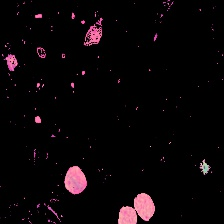


Prediction for WBC-Malignant-Early-658.jpg:
  Predicted Class: ALLPos
  Confidence: 0.9970
  All class probabilities:
    ALLNeg: 0.0030
    ALLPos: 0.9970


In [9]:
import os
from PIL import Image
from google.colab import files, drive
import numpy as np
from ultralytics import YOLO

# 1. Update paths to match your YOLO11 training results
RESULTS_DIR = "/content/drive/MyDrive/Research/Results_YOLO11"
FINAL_MODEL_PATH = os.path.join(RESULTS_DIR, "yolo11_leukemia_cls_final.pt")

# Ensure Google Drive is mounted
drive.mount("/content/drive")

# 2. Load the trained YOLO11 model
if os.path.exists(FINAL_MODEL_PATH):
    model = YOLO(FINAL_MODEL_PATH)
    print(f"Successfully loaded model from: {FINAL_MODEL_PATH}")
else:
    print(f"Error: Final model not found at {FINAL_MODEL_PATH}.")
    print("Please check your Results_YOLO11 folder in Drive.")

# 3. Handle Image Upload
print("Please upload your image file(s) now:")
uploaded = files.upload()

TEST_IMAGE_PATH = None
if uploaded:
    for filename in uploaded.keys():
        TEST_IMAGE_PATH = os.path.join("/content", filename)
        print(f"Successfully uploaded: {TEST_IMAGE_PATH}")
        break
else:
    print("No file was uploaded.")

# 4. Perform Prediction
if TEST_IMAGE_PATH and os.path.exists(TEST_IMAGE_PATH):
    img = Image.open(TEST_IMAGE_PATH)
    display(img)

    results = model.predict(source=TEST_IMAGE_PATH, imgsz=224, verbose=False)

    for r in results:
        probs = r.probs.data.cpu().numpy()
        names = r.names

        predicted_class_idx = np.argmax(probs)
        predicted_class_name = names[predicted_class_idx]
        confidence = probs[predicted_class_idx]

        print(f"\nPrediction for {os.path.basename(TEST_IMAGE_PATH)}:")
        print(f"  Predicted Class: {predicted_class_name}")
        print(f"  Confidence: {confidence:.4f}")
        print("  All class probabilities:")
        for i, prob in enumerate(probs):
            print(f"    {names[i]}: {prob:.4f}")